# FOMC statement releases: an event study

**The question.** When the Fed releases a policy statement, do rate sensitive
sectors earn abnormal returns that are different from zero, and does the effect
hit regional banks (`KRE`) harder than the broad market (`SPY`)?

**The method.** A market model event study. For each ticker and each event I
estimate alpha and beta over the 221 trading days from `t-250` to `t-30`, then
compute abnormal returns across the `[-1, +1]` window around the release. SPY
gets a constant mean model instead, since regressing a series on itself tells
you nothing. The abnormal returns are aggregated two ways: AAR, the average
across events at each offset, and CAR, the sum across the window for each
event. Significance comes from a t test and a seeded bootstrap of 10,000
resamples.

This notebook runs start to finish on a fresh clone. It rebuilds everything from
`data/events.csv` and the price cache in `data/raw/`, which `yfinance` refills
if it is missing.

In [1]:
import sys
from pathlib import Path

# Jupyter sets the kernel cwd to this notebook's own directory; src/ lives one
# level up, at the repo root.
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import pandas as pd
from scipy import stats

from src.fomc_dates import EVENTS_CSV
from src.returns import fetch_prices, to_log_returns
from src.event_study import abnormal_returns, cumulative_abnormal_returns
from src.inference import ttest_aar, bootstrap_ci, diff_in_means_ci
from src.plots import plot_aar_by_offset, plot_car_distribution

pd.set_option("display.width", 120)

## 1. Rebuild the abnormal return table

Events too close to the start of the price history get skipped, because there is
not enough room behind them for a full estimation window. The counts below make
that visible instead of letting it happen quietly.

In [2]:
events = pd.read_csv(EVENTS_CSV)
returns = to_log_returns(fetch_prices())

ar = abnormal_returns(returns, events)
car = cumulative_abnormal_returns(ar)

print(f"events in the table:                  {len(events)}")
print(f"events with a full estimation window: {ar['event_date'].nunique()}")
print(f"rows (ticker x event x offset):       {len(ar)}")
ar.head()

events in the table:                  94
events with a full estimation window: 94
rows (ticker x event x offset):       1128


,ticker,event_date,offset,date,return,abnormal_return
0,KRE,2015-01-28,-1,2015-01-27,-0.011567,0.003963
1,KRE,2015-01-28,0,2015-01-28,-0.027884,-0.012772
2,KRE,2015-01-28,1,2015-01-29,0.013503,0.003746
3,SPY,2015-01-28,-1,2015-01-27,-0.013278,-0.013905
4,SPY,2015-01-28,0,2015-01-28,-0.012907,-0.013534


## 2. Is the average abnormal return different from zero?

A one sample t test for each (ticker, offset), then a bootstrap interval on the
same numbers. Running both is the point. Where they disagree, I would rather see
it than average it away.

In [3]:
tt = ttest_aar(ar).sort_values(["ticker", "offset"]).reset_index(drop=True)

ci = []
for _, row in tt.iterrows():
    values = ar.loc[(ar.ticker == row.ticker) & (ar.offset == row.offset), "abnormal_return"].to_numpy()
    ci.append(bootstrap_ci(values))
tt["ci_lo"], tt["ci_hi"] = zip(*ci)
tt

,ticker,offset,aar,t_stat,p_value,n,ci_lo,ci_hi
0,KRE,-1,-0.000194,-0.095525,0.924103,94,-0.004112,0.003732
1,KRE,0,-0.002019,-1.126845,0.262707,94,-0.005478,0.001330
2,KRE,1,-0.001950,-1.124333,0.263765,94,-0.005440,0.001367
3,SPY,-1,0.001844,1.476865,0.143090,94,-0.000376,0.004475
4,SPY,0,-0.001490,-0.879649,0.381317,94,-0.005077,0.001586
5,SPY,1,-0.000684,-0.485214,0.628665,94,-0.003546,0.002011
6,TLT,-1,0.001437,1.749351,0.083529,94,-0.000195,0.003051
7,TLT,0,0.002976,3.393906,0.001014,94,0.001286,0.004713
8,TLT,1,-0.000733,-0.635421,0.526714,94,-0.003009,0.001455
9,XLF,-1,0.000641,0.630417,0.529968,94,-0.001304,0.002620


TLT on the release day is the one row where both methods agree. The average
abnormal return is +0.30%, the t test gives p = 0.001, and the bootstrap
interval of [0.13%, 0.47%] never touches zero. Treasuries repricing on a rate
decision is about as unsurprising as a result gets, which is a good sign that
the pipeline is doing what I think it is doing.

XLF on the release day is the disagreement worth pointing at. Its bootstrap
interval is [-0.30%, -0.003%], which stops just barely short of zero, while the
t test gives p = 0.059 and does not clear the usual 0.05 bar. Two methods, two
answers, and both of them are sitting on the line. I am not calling that a
finding.

Everything else, KRE included, is indistinguishable from zero.

## 3. The comparison I actually set out to test: KRE against SPY

Regional banks borrow short and lend long, so in theory they should be the most
rate sensitive corner of the equity market and should react harder than SPY.

The bootstrap here resamples event dates rather than tickers, which keeps each
KRE observation matched to the SPY observation from the same FOMC day. The two
move together on any given day and throwing that pairing away would inflate the
interval.

In [4]:
kre = car[car.ticker == "KRE"].sort_values("event_date")["car"].to_numpy()
spy = car[car.ticker == "SPY"].sort_values("event_date")["car"].to_numpy()

t_stat, p_value = stats.ttest_rel(kre, spy)
diff_lo, diff_hi = diff_in_means_ci(kre, spy)

print(f"mean CAR: KRE {kre.mean():.4%}, SPY {spy.mean():.4%}")
print(f"paired t test: t={t_stat:.3f}, p={p_value:.3f}")
print(f"bootstrap 95% CI for (KRE - SPY) mean CAR: [{diff_lo:.4%}, {diff_hi:.4%}]")

mean CAR: KRE -0.4163%, SPY -0.0330%
paired t test: t=-1.118, p=0.267
bootstrap 95% CI for (KRE - SPY) mean CAR: [-1.0755%, 0.2669%]


**The theory did not survive contact with the data.** KRE's average CAR is
actually a little more negative than SPY's, and the interval on the difference
runs from -1.08% to +0.27%, so it contains zero comfortably. I cannot say the
two are different.

That is a null result, not a broken pipeline. 94 events is not many, six weeks
apart is not much independence, and a three day window around a scheduled
announcement is a blunt tool for separating one sector's reaction from whatever
else the whole market did that day.

## 4. Figures

In [5]:
fig1_path = plot_aar_by_offset(ar)
fig2_path = plot_car_distribution(car)
fig1_path, fig2_path

(WindowsPath('C:/Users/gunna/OneDrive/Personal Projects/FOMC Announcement Event Study/figures/aar_by_offset.png'),
 WindowsPath('C:/Users/gunna/OneDrive/Personal Projects/FOMC Announcement Event Study/figures/car_distribution.png'))

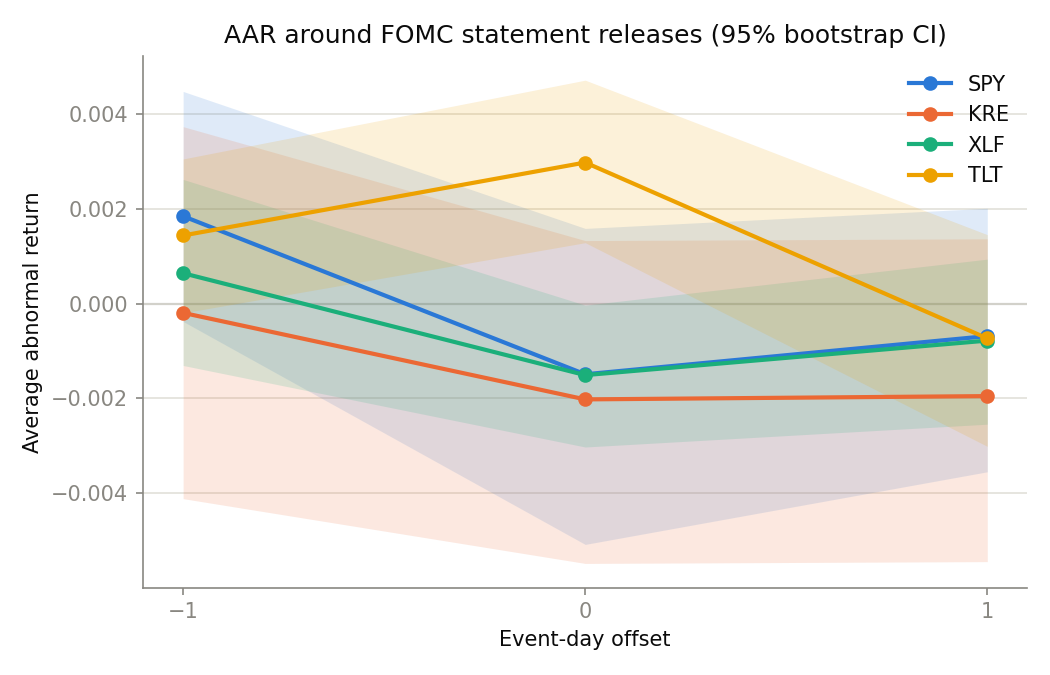

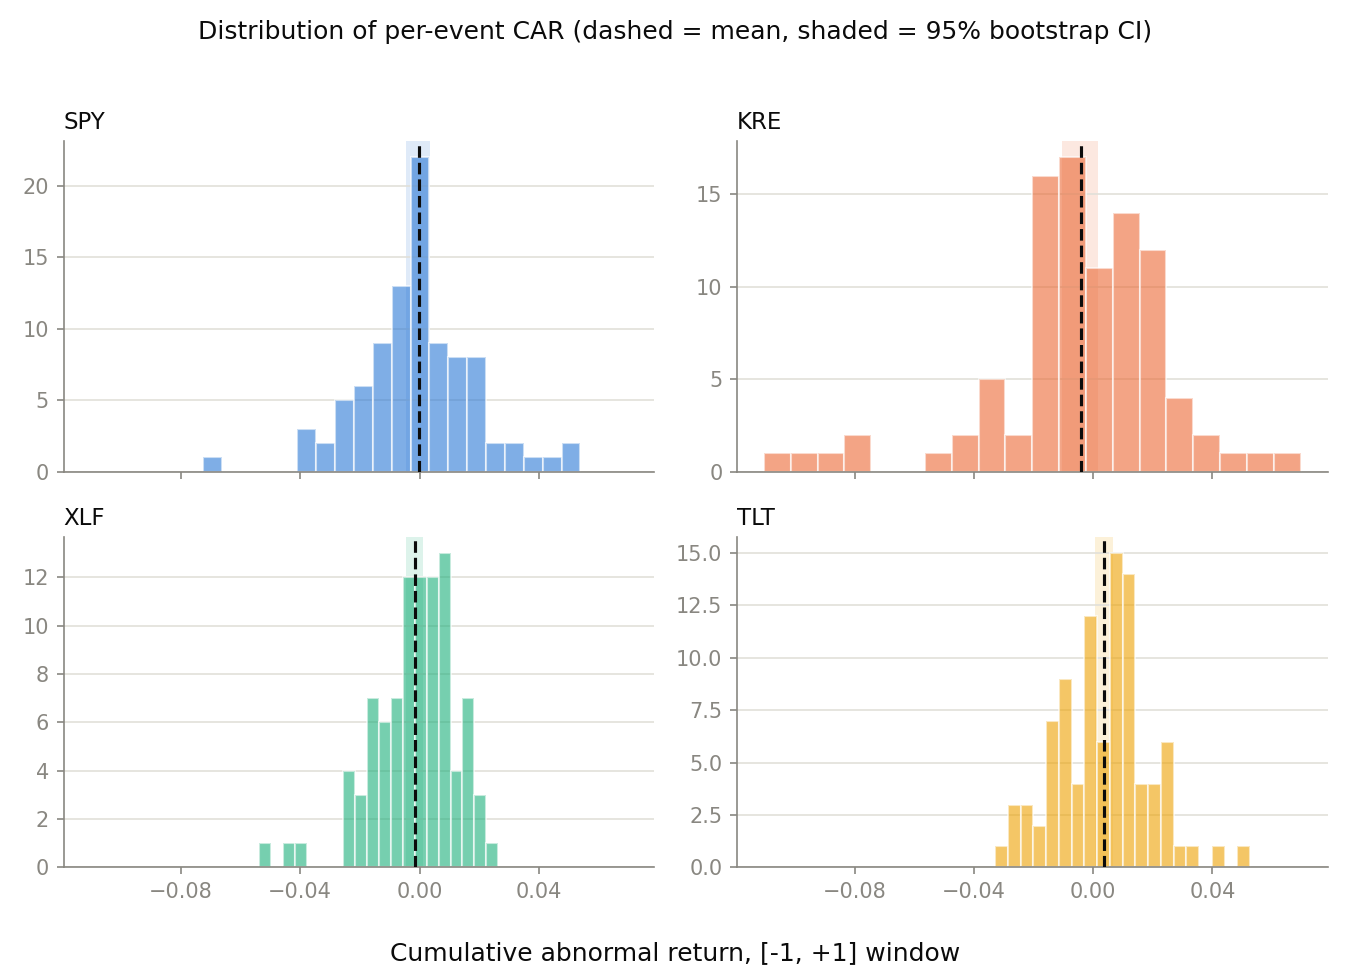

In [6]:
from IPython.display import Image, display
display(Image(filename=str(fig1_path)))
display(Image(filename=str(fig2_path)))

## 5. What would break this

- **Overlapping estimation windows.** FOMC meetings are about six weeks apart
  and the estimation window is 221 trading days, so one event's estimation
  window covers several of its neighbors. The alphas and betas are not drawn
  from independent samples, which makes their true sampling variance larger
  than the numbers here suggest.
- **Volatility clustering.** Daily returns are not i.i.d. Volatile days arrive
  in clusters, so standard errors from both the t test and the bootstrap run
  small in exactly the periods where the returns are largest. The bootstrap
  resamples whole events rather than days inside an event, so it does not fix
  this on its own.
- **2020.** Two of the 94 events are the emergency intermeeting cuts in March
  2020. KRE's average CAR on those two is -1.72% against -0.39% on the other
  92. With n = 2 that is an anecdote rather than a subgroup, but it is big
  enough to drag the full sample average, which is why the event table flags
  them as unscheduled instead of dropping them.
- **Multiple testing.** I ran 12 t tests, one per ticker and offset, plus the
  KRE against SPY comparison, and applied no correction. At an uncorrected 0.05
  threshold roughly one apparent hit in 12 shows up by luck. TLT at p = 0.001
  clears a Bonferroni threshold anyway. XLF at p = 0.059 does not clear
  anything, which is the second reason I am not claiming it.